In [11]:
import pandas as pd
data=pd.read_csv("/content/Dataset.csv")
df=pd.DataFrame(data)
df.head()
df.shape
df.dtypes
df.select_dtypes(include="number").columns.tolist()
df.select_dtypes(include=["object","category"]).columns.tolist()
df.isnull()
df.isnull().sum()
target_cols = ["CustomerID", "Age",  "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",  "Total Spend", "Last Interaction", "Churn"]

df[target_cols] = df[target_cols].fillna(df[target_cols].mean(numeric_only=True))
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440833 non-null  float64
 1   Age                440833 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440833 non-null  float64
 4   Usage Frequency    440833 non-null  float64
 5   Support Calls      440833 non-null  float64
 6   Payment Delay      440833 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440833 non-null  float64
 10  Last Interaction   440833 non-null  float64
 11  Churn              440833 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440833.000000,440833.000000,440833.000000,440833.000000,440833.000000,440833.000000,440833.000000,440833.000000,440833.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.771632,12.442355,17.255708,8.586232,3.070214,8.258053,240.802728,8.596198,0.495476
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113622.000000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.000000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.000000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [12]:
df.isnull()
df.isnull().sum()

df["Contract Length"].unique()
df["Subscription Type"].unique()
df["Gender"].unique()

categorical_columns=["Gender","Subscription Type","Contract Length"]
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


df.duplicated()
df.duplicated().sum()
df.drop_duplicates().shape[0]

for col in categorical_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip() # Strip spaces
print(df.info())

df["CustomerID"]=df["CustomerID"].astype(int)







<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440833 non-null  float64
 1   Age                440833 non-null  float64
 2   Gender             440833 non-null  object 
 3   Tenure             440833 non-null  float64
 4   Usage Frequency    440833 non-null  float64
 5   Support Calls      440833 non-null  float64
 6   Payment Delay      440833 non-null  float64
 7   Subscription Type  440833 non-null  object 
 8   Contract Length    440833 non-null  object 
 9   Total Spend        440833 non-null  float64
 10  Last Interaction   440833 non-null  float64
 11  Churn              440833 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None


In [13]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percentages)


df['Churn'] = df['Churn'].round().astype(int)


display(df['Churn'].value_counts())
display(df['Churn'].value_counts(normalize=True) * 100)

categorical_features = ['Gender', 'Subscription Type', 'Contract Length']

for feature in categorical_features:

    print(df[feature].value_counts())
    print(df[feature].value_counts(normalize=True) * 100)


Churn
1.000000    249999
0.000000    190833
0.567107         1
Name: count, dtype: int64
Churn
1.000000    56.710591
0.000000    43.289182
0.567107     0.000227
Name: proportion, dtype: float64


,count
Churn,
1,250000
0,190833


,proportion
Churn,
1,56.710818
0,43.289182


Gender
Male      250253
Female    190580
Name: count, dtype: int64
Gender
Male      56.768209
Female    43.231791
Name: proportion, dtype: float64
Subscription Type
Standard    149129
Premium     148678
Basic       143026
Name: count, dtype: int64
Subscription Type
Standard    33.828910
Premium     33.726604
Basic       32.444486
Name: proportion, dtype: float64
Contract Length
Annual       177199
Quarterly    176530
Monthly       87104
Name: count, dtype: int64
Contract Length
Annual       40.196401
Quarterly    40.044643
Monthly      19.758956
Name: proportion, dtype: float64


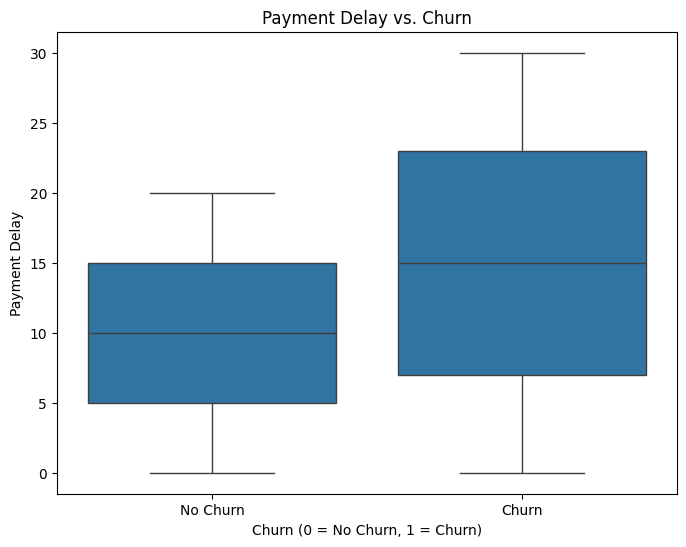

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Payment Delay', data=df)
plt.title('Payment Delay vs. Churn')
plt.xlabel('Churn (0 = No Churn, 1 = Churn)')
plt.ylabel('Payment Delay')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("/content/Dataset.csv")

target_cols = ["CustomerID", "Age",  "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",  "Total Spend", "Last Interaction", "Churn"]
df[target_cols] = df[target_cols].fillna(df[target_cols].mean(numeric_only=True))


categorical_columns=["Gender","Subscription Type","Contract Length"]
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype(str).str.strip()


df["CustomerID"]=df["CustomerID"].astype(int)


df['Churn'] = df['Churn'].round().astype(int)

X = df[['Usage Frequency', 'Payment Delay', 'Subscription Type',
        'Contract Length', 'Total Spend', 'Last Interaction', 'Gender']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)


X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("First 10 predictions:", y_pred[:10])

First 10 predictions: [1 1 1 0 1 0 0 1 1 0]


Model Accuracy: 0.81250354441004
[[31493  6650]
 [ 9881 40143]]
              precision    recall  f1-score   support

           0       0.76      0.83      0.79     38143
           1       0.86      0.80      0.83     50024

    accuracy                           0.81     88167
   macro avg       0.81      0.81      0.81     88167
weighted avg       0.82      0.81      0.81     88167

[[31493  6650]
 [ 9881 40143]]


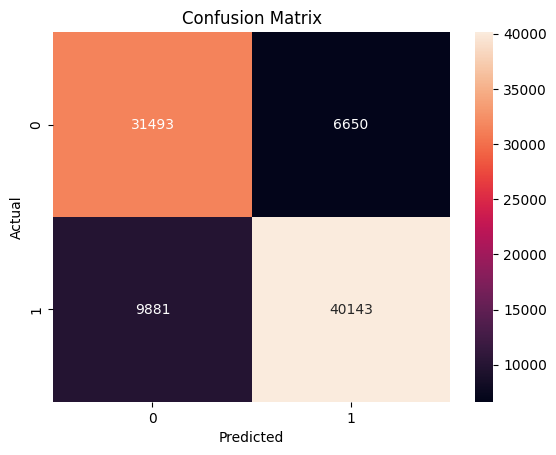

              precision    recall  f1-score   support

           0       0.76      0.83      0.79     38143
           1       0.86      0.80      0.83     50024

    accuracy                           0.81     88167
   macro avg       0.81      0.81      0.81     88167
weighted avg       0.82      0.81      0.81     88167



In [23]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

In [24]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9084351287896832
              precision    recall  f1-score   support

           0       0.84      0.98      0.90     38143
           1       0.98      0.85      0.91     50024

    accuracy                           0.91     88167
   macro avg       0.91      0.92      0.91     88167
weighted avg       0.92      0.91      0.91     88167

              precision    recall  f1-score   support

           0       0.84      0.98      0.90     38143
           1       0.98      0.85      0.91     50024

    accuracy                           0.91     88167
   macro avg       0.91      0.92      0.91     88167
weighted avg       0.92      0.91      0.91     88167



In [25]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rf)]
})

display(model_comparison.sort_values(by='Accuracy', ascending=False))

,Model,Accuracy
1,Random Forest,0.908435
0,Logistic Regression,0.812504


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    rf,
    params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [27]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    random_state=42
)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))



Accuracy: 0.9144124218812028
              precision    recall  f1-score   support

           0       0.83      1.00      0.91     38143
           1       1.00      0.85      0.92     50024

    accuracy                           0.91     88167
   macro avg       0.92      0.92      0.91     88167
weighted avg       0.93      0.91      0.91     88167



Usage Frequency : 0.001671204904960779
Payment Delay : 0.22636024984641398
Total Spend : 0.374106071153685
Last Interaction : 0.059477394988192295
Subscription Type_Basic : 0.00012376601479540582
Subscription Type_Premium : 3.9078677828588737e-05
Subscription Type_Standard : 1.741252186314054e-05
Contract Length_Annual : 0.03654180064530297
Contract Length_Monthly : 0.21459873543813796
Contract Length_Quarterly : 0.02754109368297171
Gender_Female : 0.0320825364474115
Gender_Male : 0.027440655678436662
                       Feature  Importance
2                  Total Spend    0.374106
1                Payment Delay    0.226360
8      Contract Length_Monthly    0.214599
3             Last Interaction    0.059477
7       Contract Length_Annual    0.036542
10               Gender_Female    0.032083
9    Contract Length_Quarterly    0.027541
11                 Gender_Male    0.027441
0              Usage Frequency    0.001671
4      Subscription Type_Basic    0.000124
5    Subscription Ty

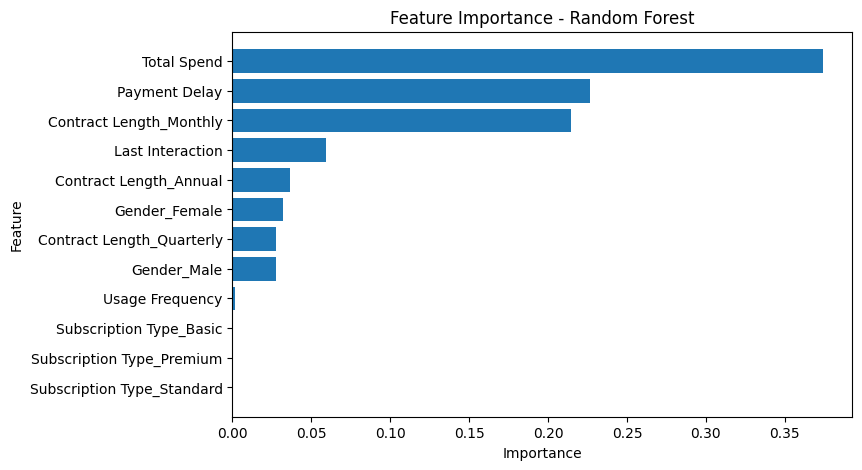

In [30]:
importance = final_model.feature_importances_

features = X_train.columns

for feature, value in zip(features, importance):
    print(feature, ":", value)
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()

plt.show()

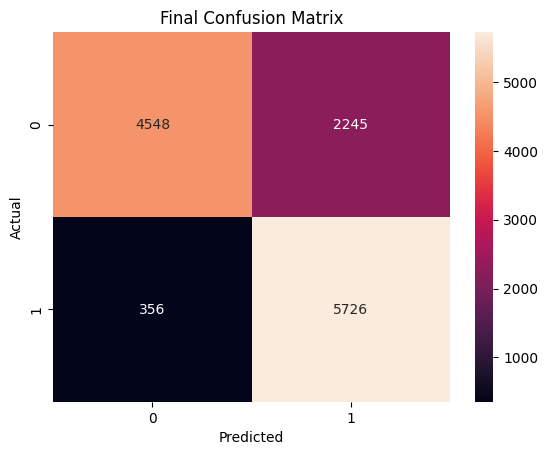

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix")
plt.show()

In [31]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    random_state=42
)
final_model.fit(X_train, y_train)
new_customer = pd.DataFrame({
    'Usage Frequency': [20],
    'Payment Delay': [15],
    'Subscription Type': ['Monthly'],
    'Contract Length': ['One Year'],
    'Total Spend': [5000],
    'Last Interaction': [10]
})
new_customer = pd.get_dummies(new_customer)
new_customer = new_customer.reindex(
    columns=X_train.columns,
    fill_value=0
)
prediction = final_model.predict(new_customer)
if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is likely to stay")

joblib.dump(final_model, "telecom_churn_model.pkl")
print("Model saved successfully!")

loaded_model = joblib.load("telecom_churn_model.pkl")
new_prediction = loaded_model.predict(new_customer)
print("Prediction from saved model:", new_prediction[0])

Customer is likely to stay
Model saved successfully!
Prediction from saved model: 0


In [28]:

loaded_model = joblib.load("telecom_churn_model.pkl")
features = joblib.load("churn_features.pkl")
prediction = loaded_model.predict(new_customer[features])
print("Prediction:", prediction[0])
if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is likely to stay")

Prediction: 0
Customer is likely to stay
